In [1]:
import numpy as np
import scipy as sp
import scipy.special as spsp
import matplotlib.pyplot as plt

## Binomial a Normal (CLT)

(0.0, 100.0)

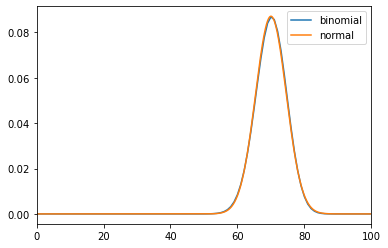

In [9]:
n = 100 # 30
p = 0.7 # para p muy pequenotodavia se tiene probabilidad para la normay deja de tener sentido, aqui necesitamos la Poisson
q = 1-p

# Creamos distribucion binomial
PXbinomial = []
for k in range(n+1):
    probX = spsp.comb(n,k) * p**k * q**(n-k)
    PXbinomial.append(probX)
    
# Creamos distribucion normal
mu = n*p
sigma = np.sqrt(n*p*q)

X = np.arange(0, n, 0.01)
PXnormal = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-((X-mu)**2)/(2*sigma**2))

# Plot
plt.plot(PXbinomial, label="binomial")
plt.plot(X, PXnormal, label="normal")
plt.legend()
plt.xlim(0,n)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [33]:
# Set the random seed for reproducibility
# np.random.seed(42)

# Genera N=10000 random samples from a Poisson distribition with a mean lambda
lambda_value= 10
N = 10000
DataPopulation = np.random.poisson(lam=lambda_value, size=N)

In [37]:
# Parameter for sampling
n = 100 
m = 1000

SampleMeans = np.zeros(m)
SampleSTDs = np.zeros(m)

for i in range(m):
    DataSample = np.random.choice( DataPopulation, size=n, replace=False)
    SampleMeans[i] = np.mean(DataSample)
    SampleSTDs[i] = np.std(DataPopulation)
# Calculate the population mean and SD
mean_population = np.mean(DataPopulation)
std_population = np.std(DataPopulation)
    

In [38]:
std_error = std_population / np.sqrt(n)

x = np.linspace(min(SampleMeans), max(SampleMeans), 100)
normal_approximation = norm.pdf(x, loc=mean_population, scale=std_error)

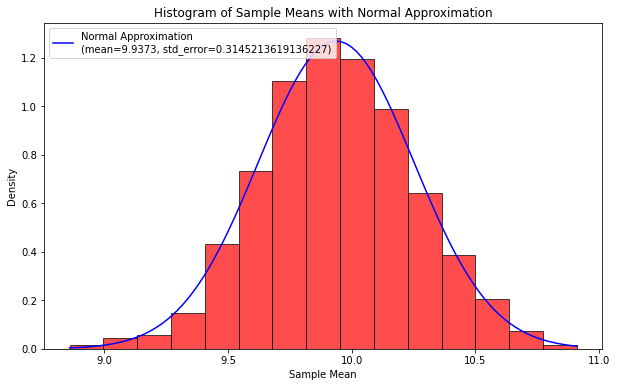

In [39]:
# plot the histogram of the SampleMeans
plt.figure(figsize=(10,6))
plt.hist(SampleMeans, bins=15, color='red', edgecolor='black', alpha=0.7, density=True)

plt.plot(x, normal_approximation, 'b-', label=f'Normal Approximation\n(mean={mean_population}, std_error={std_error})'  )

         
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title('Histogram of Sample Means with Normal Approximation')

plt.legend()
plt.show()